In [1]:
#clone my Github main branch from https://github.com/LukeTheGeneWriter/GeneWriter
!git clone https://github.com/LukeTheGeneWriter/GeneWriter.git

Cloning into 'GeneWriter'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 229 (delta 132), reused 160 (delta 67), pack-reused 0 (from 0)
Receiving objects: 100% (229/229), 3.48 MiB | 27.61 MiB/s, done.
Resolving deltas: 100% (132/132), done.


In [2]:
import pickle
import pandas as pd
import numpy as np
import random
from google.colab import drive
drive.mount('/content/drive')
%cd drive
%cd MyDrive

Mounted at /content/drive
/content/drive
/content/drive/MyDrive


: 

In [3]:
"""GeneWriter — Colab stress-test / benchmark script.

Paste this whole file into a Colab cell (or `%run` it after cloning), edit
the CONFIG block below, and run. It does three things, each independently
toggleable in CONFIG:

  1. Loads real gene data + baseline ("analysis objects") data from paths
     you point it at (Drive-mounted or local to the Colab VM).
  2. Benchmarks gpu_change_vector.batch_calculate_change_vectors() -- the
     population-batched change-vector computation -- numpy vs cupy, across
     whatever population sizes you list, so you can extend the numbers
     already on record in Handoff.md (see its "Performance numbers" section)
     onto whatever GPU Colab hands you (T4 / L4 / A100 / etc).
  3. Optionally runs the *actual* GA pipeline end to end (ga.run_ga or
     schedule.run_schedule) against a real gene, so you can sanity-check a
     real run at whatever scale, not just the isolated batched-term math.

UPDATE 3: Kmer is now batched too (gpu_change_vector.batch_kmer_term()) --
all 5 terms route through array-based batching, no per-individual Python
loop left anywhere in batch_calculate_change_vectors(). This is a large
real win for step 2's benchmark and for "input"/"kill_off"/"select"/
"flatten" (25-48x measured on real hardware, see Handoff.md sec 6, up from
~9-25x when Kmer still fell back to a per-individual loop).

"growth" (ga.directed_evolution_batch(), when xp is set and lookahead=True,
the default) benefits far less than that number suggests, for a reason
that only became visible after Kmer was batched: growth's own
alternative-scoring is now fast (measured: 1.45s for ~10,000 candidates on
real hardware), but merge_replicate()'s per-accepted-replicate storage
diffing -- one diff_change_vector() call per new genotype, entirely
untouched by any of this session's batching work -- is now what dominates
growth's cost instead (measured: ~12s for that same ~10,000 replicates).
Net effect: growth's real end-to-end speedup is a modest ~3x, not 25-48x,
and xp=cupy still measures roughly the same as xp=numpy for growth
specifically (the remaining bottleneck is a Python loop, not batched math,
so the array backend doesn't matter). Batching merge_replicate's storage
diffing across a generation the way seed_population()/
refresh_change_vectors() already batch theirs is the next real lever for
growth specifically, and is NOT started.
"""

import glob
import os
import subprocess
import sys
import time

# Populated by main() (see its `global` declaration) so the next cell can
# use them directly -- e.g. genewriter.visualize.plot_population_tsne(
# final_pop, CONFIG["WEIGHTS"], ...) -- without threading every
# intermediate result through by hand. None until main() actually runs.
final_pop = None
genes = None
analysis_objects = None
aa_seq = None
locvec = None
natural_codons = None
# ============================================================================
# CONFIG -- every option currently exposed by the codebase, in one place.
# Edit this block; the rest of the script just reads from it.
# ============================================================================

CONFIG = dict(
    # ------------------------------------------------------------------
    # Repo / environment
    # ------------------------------------------------------------------
    # Where to git-clone (or find an existing clone of) GeneWriter on the
    # Colab VM. If REPO_DIR already exists and looks like the repo, cloning
    # is skipped and it's left as-is (so re-running a cell doesn't reclone).
    REPO_URL="https://github.com/LukeTheGeneWriter/GeneWriter.git",
    REPO_DIR="/content/GeneWriter",
    GIT_REF="main",  # branch, tag, or commit to check out after cloning

    # Install numpy + (if USE_GPU) a cupy wheel via pip. Turn off if you're
    # managing the environment yourself.
    INSTALL_DEPS=True,
    # cupy wheel to install -- Colab's runtime is CUDA 12.x regardless of
    # which GPU tier you attach (T4/L4/A100/H100), so cupy-cuda12x is the
    # right wheel across all of them. Change only if Colab's CUDA version
    # has moved on.
    CUPY_PACKAGE="cupy-cuda12x",

    # Try to use the GPU (cupy) for the step-2 benchmark. Auto-falls-back to
    # numpy-only if cupy import fails or no GPU is attached (e.g. you forgot
    # to set Runtime > Change runtime type > GPU) -- the script will print
    # which backend(s) it actually ran with.
    USE_GPU=True,

    # ------------------------------------------------------------------
    # Data locations -- gene objects (real genes) and analysis objects
    # (baselines the change-vector terms score against)
    # ------------------------------------------------------------------
    # Directory of real NCBI gene JSON files (what gene_io.load_genes()
    # reads -- one *.json per gene, RefGenes/NHGeneBodySupp/<geneID>.json
    # shape). This is the gitignored Gene_Obj_Samples/ folder -- point this
    # at a Drive-mounted copy, or upload the folder into the Colab VM first.
    GENE_OBJ_DIR="/content/drive/MyDrive/RefGenes/NHGeneBodySupp",

    # Mount Google Drive automatically if GENE_OBJ_DIR (or STANDARDS_DIR)
    # points under /content/drive. No-op outside Colab or if already mounted.
    AUTO_MOUNT_DRIVE=True,

    # Directory of precomputed genome-wide baseline JSON files (what
    # standards_io.load_standards() reads: RareCodonAnalysis.json,
    # CodonUsageAnalysis.json, CodonPairBiasAnalysis.json, GCAnalysis.json,
    # KmerAnalysis.json -- the real ~18,864-gene reference set, hours to
    # regenerate). Set to None to skip and fall back to
    # COMPUTE_LOCAL_BASELINES instead.
    STANDARDS_DIR="/content/drive/MyDrive/Standards",

    # If STANDARDS_DIR is None (or a file is missing from it), compute
    # baseline analysis objects on the fly from whatever's in GENE_OBJ_DIR
    # via baseline.compute_baselines(). NOTE: per baseline.py's own
    # docstring, a handful of local sample genes is a smoke-test baseline,
    # not a scientifically meaningful reference distribution -- use
    # STANDARDS_DIR for anything beyond a quick pipeline sanity check.
    COMPUTE_LOCAL_BASELINES=True,

    # Organism label attached to computed/loaded baselines (cosmetic --
    # stored on the AnalysisObjects dataclasses, not used in scoring math).
    ORGANISM="human",

    # ------------------------------------------------------------------
    # Which real gene/isoform to run against -- only used when
    # TARGET_MODE="gene" (see below).
    # ------------------------------------------------------------------
    # geneID (int, matches NaturalGene.geneID) to target, or None to just
    # use the first protein-coding isoform found in GENE_OBJ_DIR.
    GENE_ID=None,
    # Which isoform of that gene (index into its protein-coding isoforms,
    # in the order gene_io.protein_coding_isoforms() yields them). 0 = first.
    ISOFORM_INDEX=0,

    # ------------------------------------------------------------------
    # Optimization target: a real gene/isoform ("gene", default -- uses
    # GENE_ID/ISOFORM_INDEX above) or an arbitrary user-supplied protein
    # sequence ("custom" -- bypasses gene lookup entirely, GENE_OBJ_DIR
    # doesn't even need to exist).
    # ------------------------------------------------------------------
    TARGET_MODE="custom",
    # Required if TARGET_MODE="custom". Validated via
    # codon_tables.validate_aa_sequence() -- every character must be one of
    # the 20 standard amino acids; '*' (stop codon) anywhere raises, since
    # this convention's aa_seq never carries a trailing stop symbol.
    CUSTOM_AA_SEQ="MALFARYIPPIMAQEQERLASFHNKEWQVASAALRRETIPMNCHFQYQWERTYIPASDFHKLCVNMLKLERPMPTIARMNWQERLKMCSAFPPFME",
    # Per-position 'F'/'T'/'I'/'S' exon-location tags for CUSTOM_AA_SEQ, or
    # None -> all 'I' (generic interior coding sequence -- same default
    # calculate_change_vector itself uses when it has no real exon-boundary
    # information). Must match len(CUSTOM_AA_SEQ) if given.
    CUSTOM_LOCVEC=None,

    # ------------------------------------------------------------------
    # Initial-population seeding strategy -- affects RUN_GA_OPTIONS'
    # `seeds` list and (when RUN_MODE="schedule") the "input" step's
    # ctx.seed_fn.
    # ------------------------------------------------------------------
    # "uniform" (ga.generate_seed -- pure random synonymous choice per
    # residue, unchanged default) or "ngram" (codon_ngram.
    # sample_codon_ngram_seed -- samples from codon usage patterns learned
    # from real genes, conditioned on local amino-acid context, restricted
    # to interior ('I'-tagged) codon windows by default). IMPORTANT: the
    # ngram model is only scientifically meaningful once
    # GeneDataSourcing.ipynb's check_cds_against_protein fix (already
    # applied to the notebook) has ALSO been used to regenerate the actual
    # gene JSON data -- against data generated before that fix, "ngram"
    # will run without error but won't have learned anything meaningful
    # (see codon_ngram.py's module docstring).
    SEED_STRATEGY="ngram",
    # Path to a precomputed CodonNgramModel JSON (via codon_ngram.
    # save_codon_ngram_model/load_codon_ngram_model). None builds one on
    # the fly from GENE_OBJ_DIR when SEED_STRATEGY="ngram" -- slow-ish for
    # a large gene set, same caveat as COMPUTE_LOCAL_BASELINES. If set but
    # no file exists there yet, builds one the same way and saves it to
    # this path, so the next run pointed at the same NGRAM_MODEL_PATH loads
    # instead of rebuilding.
    NGRAM_MODEL_PATH="/content/drive/MyDrive/Standards/codon_ngram_models/human.json",
    NGRAM_CONTEXT_ORDERS=(6, 5, 4, 3, 2, 1),
    NGRAM_MIN_OBSERVATIONS=5,

    # ------------------------------------------------------------------
    # Change-vector term weights -- one entry per registered term. Must
    # cover every name in change_vector.registered_terms() (currently
    # RareCodons, CodonUsage, CodonPairBias, GC, Kmer, Uracil) or
    # run_ga/run_schedule will raise. Positive weight = term counts
    # normally; 0 = term computed but ignored in scoring; negative = invert
    # the term's pressure. Uracil defaults to 0.0 (off) here -- unlike the
    # other 5 terms it isn't a natural-gene-baseline comparison, just a raw
    # "opportunity to remove a U" count (see change_vector._uracil_term's
    # docstring), and it scores *higher* for more removable U -- so a
    # *negative* weight is what actually pushes uracil content down if you
    # enable it.
    # ------------------------------------------------------------------
    WEIGHTS=dict(RareCodons=1.0, CodonUsage=1.0, CodonPairBias=1.0, GC=1.0, Kmer=1.0, Uracil=0.0),

    # If True, override WEIGHTS for every term with a natural-gene per-gene
    # baseline array (RareCodons, CodonUsage, CodonPairBias, GC -- see
    # weight_calibration.py) using compute_intolerance_weights(): a term
    # real genes barely vary in gene-to-gene gets a proportionally larger
    # weight (nature is intolerant of perturbing it), one they vary a lot in
    # gets a proportionally smaller one -- scaled so the calibrated terms
    # still average to 1.0 (same scale as leaving every WEIGHTS entry at
    # 1.0). Kmer (no per-gene baseline) and Uracil (not a natural-baseline
    # term at all -- see change_vector._uracil_term's docstring) always
    # keep their WEIGHTS value regardless of this flag.
    USE_INTOLERANCE_WEIGHTS=True,

    # ------------------------------------------------------------------
    # Step 2: batched change-vector GPU benchmark
    # ------------------------------------------------------------------
    RUN_BATCH_BENCHMARK=False,
    # Population sizes to benchmark at, one pass per size. Handoff.md's own
    # numbers cover 1,000 and 10,000 on an RTX 3050 (4GB) -- push higher
    # here on a bigger-memory Colab GPU (A100 40/80GB) to see where the
    # numpy/GPU crossover and any further speedup gains land.
    BENCHMARK_POP_SIZES=[1_000, 10_000, 50_000],
    # How the benchmark population's genotypes are generated: "random" seeds
    # every individual independently via ga.generate_seed() (fast, but no
    # realistic mutation clustering); "mutated" starts from one real seed and
    # applies a handful of random synonymous mutations per individual
    # (closer to what an actual GA generation's offspring look like).
    BENCHMARK_POP_MODE="mutated",
    BENCHMARK_MUTATION_RATE=0.05,  # only used when BENCHMARK_POP_MODE="mutated"

    # ------------------------------------------------------------------
    # Step 3: run the actual GA pipeline end to end (optional)
    # ------------------------------------------------------------------
    RUN_PIPELINE=True,
    # "run_ga"   -- ga.run_ga(): simple fixed-shape generation loop.
    # "schedule" -- schedule.run_schedule(): declarative step list, see
    #               SCHEDULE below. Prefer this for anything past a quick
    #               smoke test -- it lets you batch several cheap growth
    #               steps between exact-refresh checkpoints.
    RUN_MODE="schedule",

    # Which array backend to route the pipeline's whole-population exact
    # recomputes through (seeding + kill_off/select/flatten refreshes -- see
    # module docstring): "gpu" (cupy, falls back to numpy if unavailable),
    # "numpy" (batched but CPU-only -- still faster than the per-individual
    # path per Handoff.md's own numbers), or "none" (original per-individual
    # path, xp=None, for an apples-to-apples before/after comparison).
    PIPELINE_XP_BACKEND="gpu",

    # Diagnostic-only progress logging for step 3 (no effect on the run's
    # results) -- turn this on before assuming a slow/stuck-looking run is a
    # bug. PROGRESS prints per-generation/per-step timing; PROGRESS_EVERY
    # additionally prints throughput within growth/refresh/seeding loops.
    # This is what originally caught growth's lookahead scoring being
    # ~20-27 individuals/sec (tens of times slower than the batched refresh
    # path), and later caught that batching growth's scoring wasn't enough
    # on its own -- merge_replicate()'s per-replicate storage diffing
    # (still per-individual, unaffected by xp) became the new dominant cost
    # once scoring got fast (see Handoff.md sec 6 and RUN_GA_OPTIONS.lookahead
    # below). Turn this on before assuming a slow run is a bug rather than
    # a known, already-diagnosed cost.
    PROGRESS=True,
    PROGRESS_EVERY=200,

    # --- options used when RUN_MODE == "run_ga" (ga.run_ga signature) ---
    RUN_GA_OPTIONS=dict(
        num_gens=10,                # generations to run
        target_size=None,           # cap population to this many distinct
                                     # individuals after each generation
                                     # (None = defaults to initial seed count)
        locvec=None,                # per-position 'F'/'T'/'I'/'S' exon tags;
                                     # None here means "use the real gene's
                                     # tags" -- filled in below from the
                                     # chosen isoform, not left as None
        flatten_every=None,         # run flatten_generation() every N gens
                                     # instead of plain reproduction (None =
                                     # off). Trades replicate concentration
                                     # for neighborhood breadth.
        flatten_recursion_limit=3,  # how many cash-in rounds flatten does
        lookahead=False,             # directed_evolution: score every
                                     # synonymous alt at the chosen position
                                     # (True) vs pick one at random (False,
                                     # cheaper). When PIPELINE_XP_BACKEND is
                                     # "none", NOT "cheaper" as in a minor
                                     # optimization -- measured at
                                     # ~20-27 individuals/sec per-individual.
                                     # When PIPELINE_XP_BACKEND is "gpu" or
                                     # "numpy", lookahead=True routes through
                                     # the batched directed_evolution_batch()
                                     # instead -- its own scoring is now fast
                                     # (Kmer is batched too), but growth's
                                     # *other* per-replicate cost
                                     # (merge_replicate's storage diffing,
                                     # still unbatched) caps the real
                                     # end-to-end win at ~3x, not the 25-48x
                                     # the exact-refresh steps get -- see
                                     # Handoff.md sec 6. Set False here if
                                     # even that isn't fast enough and
                                     # picking the single best alternative
                                     # per mutation isn't essential.
        refresh_every=5,            # force an exact change-vector recompute
                                     # every N generations (0/None = never,
                                     # fastest but drift is unbounded; 1 =
                                     # always exact)
        save_dir="/content/drive/MyDrive/SyntheticGenes",  # per-generation population
                                               # checkpoints; None = don't save
        run_name="colab_stress_test",
    ),

    # --- schedule used when RUN_MODE == "schedule" (schedule.run_schedule)
    # Each dict's "kind" must be one of schedule.registered_steps():
    #   input      {"count": N}                       -- add N random seeds
    #   growth     {"rate", "mutation_chance",         -- reproduce every
    #               "directed_fraction", "lookahead"}     individual
    #   kill_off   {"percent_cut"}                     -- proportional cull
    #   natural_range_cutoff {"threshold"}             -- hard per-category
    #               natural-baseline sigma cutoff (see ga.
    #               kill_off_outside_natural_range())
    #   select     {"target_size"}                     -- cap distinct pop
    #   flatten    {"recursion_limit"}                 -- breadth trade
    #   save       {}                                  -- checkpoint now
    #   repeat     {"times", "steps": [...]}            -- nested sub-schedule
    SCHEDULE=[
        {"kind": "input", "count": 2000},
        {"kind": "growth", "rate": 4, "mutation_chance": 0.1, "directed_fraction": 0.5, "lookahead": True},
        {"kind": "kill_off", "percent_cut": 30},
        {"kind": "repeat", "times": 5, "steps": [
            {"kind": "growth", "rate": 7, "mutation_chance": 0.05},
            {"kind": "select", "target_size": 5000},
        ]},
        {"kind": "flatten", "recursion_limit": 3},
        {"kind": "directed_growth", "rate": 6, "lookahead": True},
        {"kind": "repeat", "times": 5, "steps": [
            {"kind": "growth", "rate": 7, "mutation_chance": 0.05},
            {"kind": "select", "target_size": 5000},
        ]},
        {"kind": "flatten", "recursion_limit": 3},
        {"kind": "directed_growth", "rate": 4, "lookahead": True},
        {"kind": "kill_off", "percent_cut": 60},
        {"kind": "directed_growth", "rate": 3, "lookahead": True},
        {"kind": "kill_off", "percent_cut": 30},
        {"kind": "directed_growth", "rate": 2, "lookahead": True},
        {"kind": "select", "target_size": 1000},
    ],
    SCHEDULE_SAVE_DIR="/content/drive/MyDrive/SyntheticGenes",
    SCHEDULE_RUN_NAME="colab_stress_test_schedule",
)

# ============================================================================
# Setup: clone repo, install deps, import GeneWriter
# ============================================================================


def _sh(cmd, **kw):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True, **kw)


def setup_environment(cfg):
    if not os.path.isdir(os.path.join(cfg["REPO_DIR"], ".git")):
        _sh(f"git clone {cfg['REPO_URL']} {cfg['REPO_DIR']}")
    _sh(f"git -C {cfg['REPO_DIR']} fetch origin")
    _sh(f"git -C {cfg['REPO_DIR']} checkout {cfg['GIT_REF']}")
    _sh(f"git -C {cfg['REPO_DIR']} pull origin {cfg['GIT_REF']}")

    if cfg["INSTALL_DEPS"]:
        _sh(f"{sys.executable} -m pip install -q numpy pytest")
        if cfg["USE_GPU"]:
            _sh(f"{sys.executable} -m pip install -q {cfg['CUPY_PACKAGE']}")

    src_dir = os.path.join(cfg["REPO_DIR"], "src")
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    if cfg["AUTO_MOUNT_DRIVE"]:
        needs_drive = any(
            str(cfg.get(k) or "").startswith("/content/drive")
            for k in ("GENE_OBJ_DIR", "STANDARDS_DIR")
        )
        if needs_drive and not os.path.isdir("/content/drive/MyDrive"):
            try:
                from google.colab import drive  # noqa: PLC0415
                drive.mount("/content/drive")
            except ImportError:
                print("Not running in Colab (or google.colab unavailable) -- skipping Drive mount.")


def detect_gpu_backend(cfg):
    """Returns (xp_module_or_None, label). None means GPU unavailable/off --
    callers fall back to numpy-only."""
    if not cfg["USE_GPU"]:
        return None, "GPU disabled in CONFIG"
    try:
        import cupy as cp
        cp.cuda.Device(0).compute_capability  # forces a real device query
        name = cp.cuda.runtime.getDeviceProperties(0)["name"].decode()
        return cp, name
    except Exception as e:  # noqa: BLE001 -- diagnostic fallback, any failure just disables GPU
        return None, f"cupy unavailable ({e})"


# ============================================================================
# Data loading: gene objects (real genes) + analysis objects (baselines)
# ============================================================================


def load_gene_data(cfg):
    from genewriter import baseline, gene_io, standards_io

    if not os.path.isdir(cfg["GENE_OBJ_DIR"]):
        raise FileNotFoundError(
            f"GENE_OBJ_DIR does not exist: {cfg['GENE_OBJ_DIR']!r}. Point it at a "
            f"folder of real NCBI gene JSONs (Gene_Obj_Samples/-shaped)."
        )
    genes = gene_io.load_genes(cfg["GENE_OBJ_DIR"])
    if not genes:
        raise FileNotFoundError(f"No *.json gene files found in {cfg['GENE_OBJ_DIR']!r}.")
    print(f"Loaded {len(genes)} gene(s) from {cfg['GENE_OBJ_DIR']}")

    analysis_objects = None
    if cfg["STANDARDS_DIR"]:
        try:
            analysis_objects = standards_io.load_standards(cfg["STANDARDS_DIR"])
            print(f"Loaded genome-wide baselines from {cfg['STANDARDS_DIR']}")
        except FileNotFoundError as e:
            print(f"STANDARDS_DIR set but incomplete/missing ({e}); "
                  f"falling back to COMPUTE_LOCAL_BASELINES.")

    if analysis_objects is None:
        if not cfg["COMPUTE_LOCAL_BASELINES"]:
            raise RuntimeError(
                "No usable STANDARDS_DIR and COMPUTE_LOCAL_BASELINES is False -- "
                "no analysis objects to score against."
            )
        analysis_objects = baseline.compute_baselines(genes, organism=cfg["ORGANISM"])
        print(f"Computed local-sample baselines from {len(genes)} loaded gene(s) "
              f"(smoke-test quality only -- see baseline.py docstring).")

    return genes, analysis_objects


def pick_target(cfg, genes):
    """Returns (aa_seq, locvec, natural_codons) for either a custom
    sequence (TARGET_MODE="custom", bypasses gene lookup entirely --
    `genes` is accepted but never touched) or the configured
    GENE_ID/ISOFORM_INDEX (TARGET_MODE="gene", default) -- locvec is the
    real 'F'/'T'/'I'/'S' location tag per residue, taken straight from the
    chosen isoform's codon list rather than defaulted to all-'I'.

    natural_codons: the real isoform's own codon list (list[str], same
    length as aa_seq) for TARGET_MODE="gene" -- lets
    visualize.plot_population_trajectory's natural_codons argument embed
    nature's own sequence in the same t-SNE space as the GA's population.
    None for TARGET_MODE="custom" (no real gene at all) or if the
    isoform's codon count doesn't match len(aa_seq) (malformed data --
    can't safely embed alongside same-length GA individuals)."""
    if cfg["TARGET_MODE"] == "custom":
        from genewriter.codon_tables import validate_aa_sequence

        if not cfg["CUSTOM_AA_SEQ"]:
            raise ValueError("TARGET_MODE='custom' requires CUSTOM_AA_SEQ to be set")
        aa_seq = validate_aa_sequence(cfg["CUSTOM_AA_SEQ"])
        locvec = cfg["CUSTOM_LOCVEC"] if cfg["CUSTOM_LOCVEC"] is not None else ["I"] * len(aa_seq)
        if len(locvec) != len(aa_seq):
            raise ValueError(f"CUSTOM_LOCVEC length ({len(locvec)}) must match CUSTOM_AA_SEQ length ({len(aa_seq)})")
        print(f"Target: custom sequence, {len(aa_seq)} residues (no gene lookup)")
        return aa_seq, locvec, None

    if cfg["TARGET_MODE"] != "gene":
        raise ValueError(f"Unknown TARGET_MODE: {cfg['TARGET_MODE']!r} (must be 'gene' or 'custom')")

    from genewriter.gene_io import protein_coding_isoforms

    candidates = list(protein_coding_isoforms(genes))
    if cfg["GENE_ID"] is not None:
        candidates = [(g, iso) for g, iso in candidates if g.geneID == cfg["GENE_ID"]]
        if not candidates:
            # Distinguish "no gene with this ID was loaded at all" (typo,
            # wrong ID, wrong GENE_OBJ_DIR) from "the gene exists but every
            # isoform was filtered out by protein_coding_isoforms()" (only
            # computationally-predicted transcripts -- 'X' in
            # isoformNumber -- or an empty codon list) -- worth telling
            # apart on a dataset that takes 30+ minutes to load (real
            # Colab run: 18,864 genes + genome-wide Standards), where a
            # vague error means burning another 30 minutes to find out
            # which case it was.
            matching_genes = [g for g in genes if g.geneID == cfg["GENE_ID"]]
            if not matching_genes:
                raise ValueError(
                    f"No gene with geneID={cfg['GENE_ID']!r} was loaded from GENE_OBJ_DIR "
                    f"({len(genes)} gene(s) loaded total) -- check the ID and that its JSON "
                    f"file is actually present in that directory."
                )
            iso_summary = [
                f"isoform {iso.isoformNumber!r} ({len(iso.codons)} codons)"
                for g in matching_genes for iso in g.isoforms
            ]
            raise ValueError(
                f"geneID={cfg['GENE_ID']!r} was loaded ({matching_genes[0].geneName}) but has no "
                f"protein-coding isoform -- protein_coding_isoforms() skips isoforms with 'X' in "
                f"isoformNumber (computationally-predicted-only) or an empty codon list. "
                f"This gene's isoform(s): {iso_summary}. Pick a different GENE_ID."
            )
    if not candidates:
        raise ValueError("No protein-coding isoforms found at all in the loaded genes.")

    idx = cfg["ISOFORM_INDEX"]
    if idx >= len(candidates):
        raise ValueError(f"ISOFORM_INDEX={idx} out of range (only {len(candidates)} available)")
    gene, iso = candidates[idx]

    aa_seq = iso.associatedProtein.aaSeq
    locvec = [loc for _codon, loc in iso.codons][:len(aa_seq)]
    if len(locvec) < len(aa_seq):
        locvec += ["I"] * (len(aa_seq) - len(locvec))

    natural_codons = [codon for codon, _loc in iso.codons]
    if len(natural_codons) != len(aa_seq):
        print(f"Isoform's codon count ({len(natural_codons)}) doesn't match aa_seq length "
              f"({len(aa_seq)}) -- natural_codons omitted (visualize.plot_population_trajectory's "
              f"natural_codons argument needs it to match the GA population's codon length exactly).")
        natural_codons = None

    print(f"Target: gene {gene.geneID} ({gene.geneName}), isoform {iso.isoformNumber}, "
          f"{len(aa_seq)} residues")
    return aa_seq, locvec, natural_codons


# ============================================================================
# Step 2: batched change-vector benchmark (numpy vs cupy)
# ============================================================================


def _make_benchmark_population(cfg, aa_seq, size):
    from genewriter.ga import generate_seed, replicate_and_mutate_random

    if cfg["BENCHMARK_POP_MODE"] == "random":
        return [generate_seed(aa_seq) for _ in range(size)]

    seed = generate_seed(aa_seq)
    pop = [seed]
    while len(pop) < size:
        pop.extend(replicate_and_mutate_random(
            seed, aa_seq, nreplicates=min(50, size - len(pop)),
            mutation_rate=cfg["BENCHMARK_MUTATION_RATE"],
        ))
    return pop[:size]


def run_batch_benchmark(cfg, aa_seq, locvec, analysis_objects, xp_gpu, gpu_label):
    import numpy as np
    from genewriter.gpu_change_vector import batch_calculate_change_vectors

    print("\n=== Step 2: batched change-vector benchmark ===")
    print(f"GPU backend: {gpu_label}")
    header = f"{'pop_size':>10} | {'numpy (s)':>10} | {'gpu (s)':>10} | {'speedup':>8}"
    print(header)
    print("-" * len(header))

    progress_every = cfg["PROGRESS_EVERY"] if cfg["PROGRESS"] else None

    for size in cfg["BENCHMARK_POP_SIZES"]:
        print(f"\nbuilding benchmark population of {size}...")
        t0 = time.perf_counter()
        pop_codons = _make_benchmark_population(cfg, aa_seq, size)
        print(f"  built {size} in {time.perf_counter() - t0:.2f}s")

        t0 = time.perf_counter()
        batch_calculate_change_vectors(pop_codons, analysis_objects, locvec, xp=np, progress_every=progress_every)
        numpy_time = time.perf_counter() - t0

        gpu_time_str = "n/a"
        speedup_str = "n/a"
        if xp_gpu is not None:
            batch_calculate_change_vectors(pop_codons, analysis_objects, locvec, xp=xp_gpu)  # warm up JIT/alloc
            t0 = time.perf_counter()
            batch_calculate_change_vectors(pop_codons, analysis_objects, locvec, xp=xp_gpu, progress_every=progress_every)
            gpu_time = time.perf_counter() - t0
            gpu_time_str = f"{gpu_time:.3f}"
            speedup_str = f"{numpy_time / gpu_time:.1f}x" if gpu_time > 0 else "inf"

        print(f"{size:>10} | {numpy_time:>10.3f} | {gpu_time_str:>10} | {speedup_str:>8}")

    print("\n(Kmer is not batched -- see gpu_change_vector.py's module docstring -- "
          "so it runs as a per-individual Python loop inside every row above, "
          "which dilutes the measured GPU speedup vs. Handoff.md's 4-term-only numbers.)")


# ============================================================================
# Step 3: run the actual GA pipeline end to end
# ============================================================================


def _resolve_pipeline_xp(cfg, xp_gpu):
    backend = cfg["PIPELINE_XP_BACKEND"]
    if backend == "none":
        return None
    if backend == "numpy":
        import numpy as np
        return np
    if backend == "gpu":
        if xp_gpu is None:
            print("PIPELINE_XP_BACKEND='gpu' but no GPU backend detected -- falling back to numpy.")
            import numpy as np
            return np
        return xp_gpu
    raise ValueError(f"Unknown PIPELINE_XP_BACKEND: {backend!r} (must be 'gpu', 'numpy', or 'none')")


def _build_seed_fn(cfg, genes):
    """Returns a callable aa_seq -> list[codon_str] per SEED_STRATEGY.
    "uniform" (default) is ga.generate_seed, unchanged. "ngram" loads (if
    NGRAM_MODEL_PATH is set and the file exists) or builds (from genes,
    otherwise) a CodonNgramModel and returns a partial around
    codon_ngram.sample_codon_ngram_seed -- see that module's docstring for
    why this is only scientifically meaningful against gene data generated
    after GeneDataSourcing.ipynb's check_cds_against_protein fix. If
    NGRAM_MODEL_PATH is set but doesn't point at an existing file yet, the
    freshly built model is saved there too, so subsequent runs pointed at
    the same path load instead of rebuilding."""
    if cfg["SEED_STRATEGY"] == "uniform":
        from genewriter.ga import generate_seed
        return generate_seed

    if cfg["SEED_STRATEGY"] == "ngram":
        import functools

        from genewriter.codon_ngram import (
            build_codon_ngram_model, load_codon_ngram_model, sample_codon_ngram_seed,
            save_codon_ngram_model,
        )

        model_path = cfg["NGRAM_MODEL_PATH"]
        if model_path and os.path.isfile(model_path):
            model = load_codon_ngram_model(model_path)
            print(f"Loaded codon n-gram model from {model_path}")
        else:
            reason = "no NGRAM_MODEL_PATH set" if not model_path else f"{model_path!r} not found"
            print(f"Building codon n-gram model from GENE_OBJ_DIR (SEED_STRATEGY='ngram', {reason})...")
            model = build_codon_ngram_model(
                genes, organism=cfg["ORGANISM"], context_orders=cfg["NGRAM_CONTEXT_ORDERS"],
            )
            if model_path:
                save_codon_ngram_model(model, model_path)
                print(f"Saved codon n-gram model to {model_path}")
        return functools.partial(sample_codon_ngram_seed, model=model, min_observations=cfg["NGRAM_MIN_OBSERVATIONS"])

    raise ValueError(f"Unknown SEED_STRATEGY: {cfg['SEED_STRATEGY']!r} (must be 'uniform' or 'ngram')")


def _resolve_weights(cfg, analysis_objects):
    """Returns the WEIGHTS dict actually used for a pipeline run:
    cfg["WEIGHTS"] unchanged, unless USE_INTOLERANCE_WEIGHTS is True, in
    which case terms with a natural-gene per-gene baseline (RareCodons,
    CodonUsage, CodonPairBias, GC) are recalibrated via
    weight_calibration.compute_intolerance_weights() -- see that module's
    docstring for the reasoning (tighter natural per-gene distribution ->
    proportionally larger weight). Kmer/Uracil (no per-gene baseline to
    calibrate from -- see that function's docstring) always keep their
    cfg["WEIGHTS"] value."""
    if not cfg["USE_INTOLERANCE_WEIGHTS"]:
        return cfg["WEIGHTS"]

    from genewriter.weight_calibration import compute_intolerance_weights

    weights = compute_intolerance_weights(analysis_objects, fallback_weights=cfg["WEIGHTS"])
    print(f"USE_INTOLERANCE_WEIGHTS=True -- calibrated WEIGHTS from natural-gene per-gene variance: {weights}")
    return weights


def run_pipeline(cfg, aa_seq, locvec, analysis_objects, xp_gpu, genes):
    from genewriter.change_vector import registered_terms, require_weights

    weights = _resolve_weights(cfg, analysis_objects)
    cfg["WEIGHTS"] = weights  # keep cfg["WEIGHTS"] consistent with what actually scored this run (e.g. cell 4's visualization reads CONFIG["WEIGHTS"] after the fact) even when USE_INTOLERANCE_WEIGHTS recalibrated it
    require_weights(registered_terms().keys(), weights)

    xp = _resolve_pipeline_xp(cfg, xp_gpu)
    xp_label = "none (per-individual)" if xp is None else getattr(xp, "__name__", str(xp))
    print(f"\n=== Step 3: running actual pipeline (mode={cfg['RUN_MODE']!r}, xp={xp_label}) ===")

    seed_fn = _build_seed_fn(cfg, genes)

    if cfg["RUN_MODE"] == "run_ga":
        from genewriter.ga import run_ga

        opts = dict(cfg["RUN_GA_OPTIONS"])
        opts["locvec"] = locvec  # override the placeholder None with the real tags
        opts["xp"] = xp
        opts["progress"] = cfg["PROGRESS"]
        opts["progress_every"] = cfg["PROGRESS_EVERY"]
        num_seeds = opts.pop("num_seeds", 200)
        seeds = [seed_fn(aa_seq) for _ in range(num_seeds)]

        t0 = time.perf_counter()
        final_pop = run_ga(aa_seq, seeds, weights, analysis_objects, **opts)
        elapsed = time.perf_counter() - t0

    elif cfg["RUN_MODE"] == "schedule":
        from genewriter.schedule import run_schedule

        t0 = time.perf_counter()
        final_pop = run_schedule(
            aa_seq, weights, analysis_objects, cfg["SCHEDULE"],
            locvec=locvec, save_dir=cfg["SCHEDULE_SAVE_DIR"], run_name=cfg["SCHEDULE_RUN_NAME"], xp=xp,
            progress=cfg["PROGRESS"], progress_every=cfg["PROGRESS_EVERY"], seed_fn=seed_fn,
        )
        elapsed = time.perf_counter() - t0

    else:
        raise ValueError(f"Unknown RUN_MODE: {cfg['RUN_MODE']!r} (must be 'run_ga' or 'schedule')")

    print(f"Final population: {len(final_pop)} distinct individuals in {elapsed:.1f}s")
    return final_pop


# ============================================================================
# Entry point
# ============================================================================


def main(cfg=CONFIG):
    # Without this, assigning these names below would create NEW locals
    # scoped to main() instead of updating the module-level placeholders
    # declared above CONFIG -- the next cell (which reads e.g. `final_pop`
    # as a bare name) would then always see None, regardless of how the
    # run actually went. This was previously worked around by hand --
    # copying each result out of a call to run_pipeline()/pick_target()
    # into a notebook-global variable after the fact -- which this makes
    # unnecessary.
    global final_pop, genes, analysis_objects, aa_seq, locvec, natural_codons

    setup_environment(cfg)
    xp_gpu, gpu_label = detect_gpu_backend(cfg)

    genes, analysis_objects = load_gene_data(cfg)
    aa_seq, locvec, natural_codons = pick_target(cfg, genes)

    if cfg["RUN_BATCH_BENCHMARK"]:
        final_pop = run_batch_benchmark(cfg, aa_seq, locvec, analysis_objects, xp_gpu, gpu_label)

    if cfg["RUN_PIPELINE"]:
        final_pop = run_pipeline(cfg, aa_seq, locvec, analysis_objects, xp_gpu, genes)


if __name__ == "__main__":
    main()

# ----------------------------------------------------------------------------
# Real-scale note: loading the actual reference set is slow -- confirmed on
# a real Colab run at 18,864 genes + genome-wide Standards baselines, load
# alone took ~30 minutes. main() reloads on every call, so re-running it
# just to try a different GENE_ID/RUN_MODE/CONFIG option pays that cost
# again. In a Colab notebook (not this script's __main__ block), prefer
# calling the pieces across separate cells so genes/analysis_objects stay in
# memory between iterations:
#
#   # cell 1 (~30 min on the real reference set, run once per session)
#   setup_environment(CONFIG)
#   xp_gpu, gpu_label = detect_gpu_backend(CONFIG)
#   genes, analysis_objects = load_gene_data(CONFIG)
#
#   # cell 2 (seconds -- re-run freely while iterating on GENE_ID etc.)
#   CONFIG["GENE_ID"] = 326
#   aa_seq, locvec, natural_codons = pick_target(CONFIG, genes)
#   run_pipeline(CONFIG, aa_seq, locvec, analysis_objects, xp_gpu, genes)

$ git -C /content/GeneWriter fetch origin
$ git -C /content/GeneWriter checkout main
$ git -C /content/GeneWriter pull origin main
$ /usr/bin/python3 -m pip install -q numpy pytest
$ /usr/bin/python3 -m pip install -q cupy-cuda12x
Loaded 6876 gene(s) from /content/drive/MyDrive/RefGenes/NHGeneBodySupp
Loaded genome-wide baselines from /content/drive/MyDrive/Standards
Target: custom sequence, 96 residues (no gene lookup)
USE_INTOLERANCE_WEIGHTS=True -- calibrated WEIGHTS from natural-gene per-gene variance: {'RareCodons': np.float64(0.17468010624550612), 'CodonUsage': np.float64(2.4187867983839793), 'CodonPairBias': np.float64(0.4065330953705144), 'GC': 1.0, 'Kmer': 1.0, 'Uracil': 0.0}

=== Step 3: running actual pipeline (mode='schedule', xp=cupy) ===
Loaded codon n-gram model from /content/drive/MyDrive/Standards/codon_ngram_models/human.json
[schedule] input {'count': 2000} starting, pop=0
  [batch_calculate_change_vectors] RareCodons for 2000 individuals done in 2.52s
  [batch_calcu

: 

#Now lets visualize the results

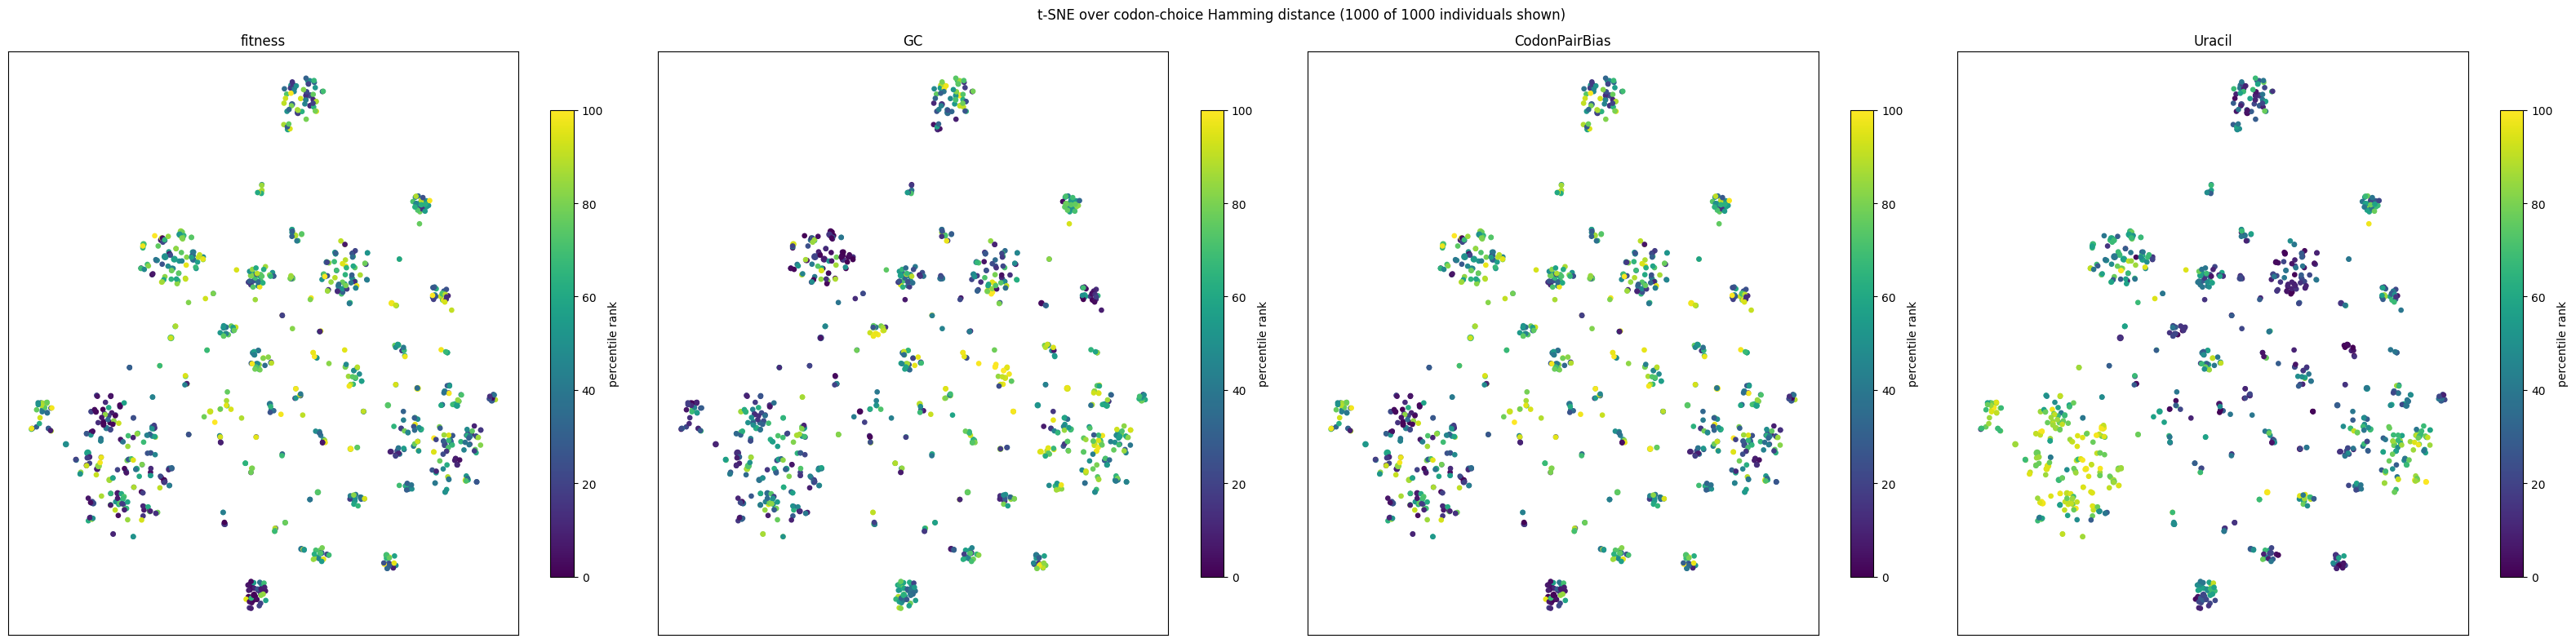

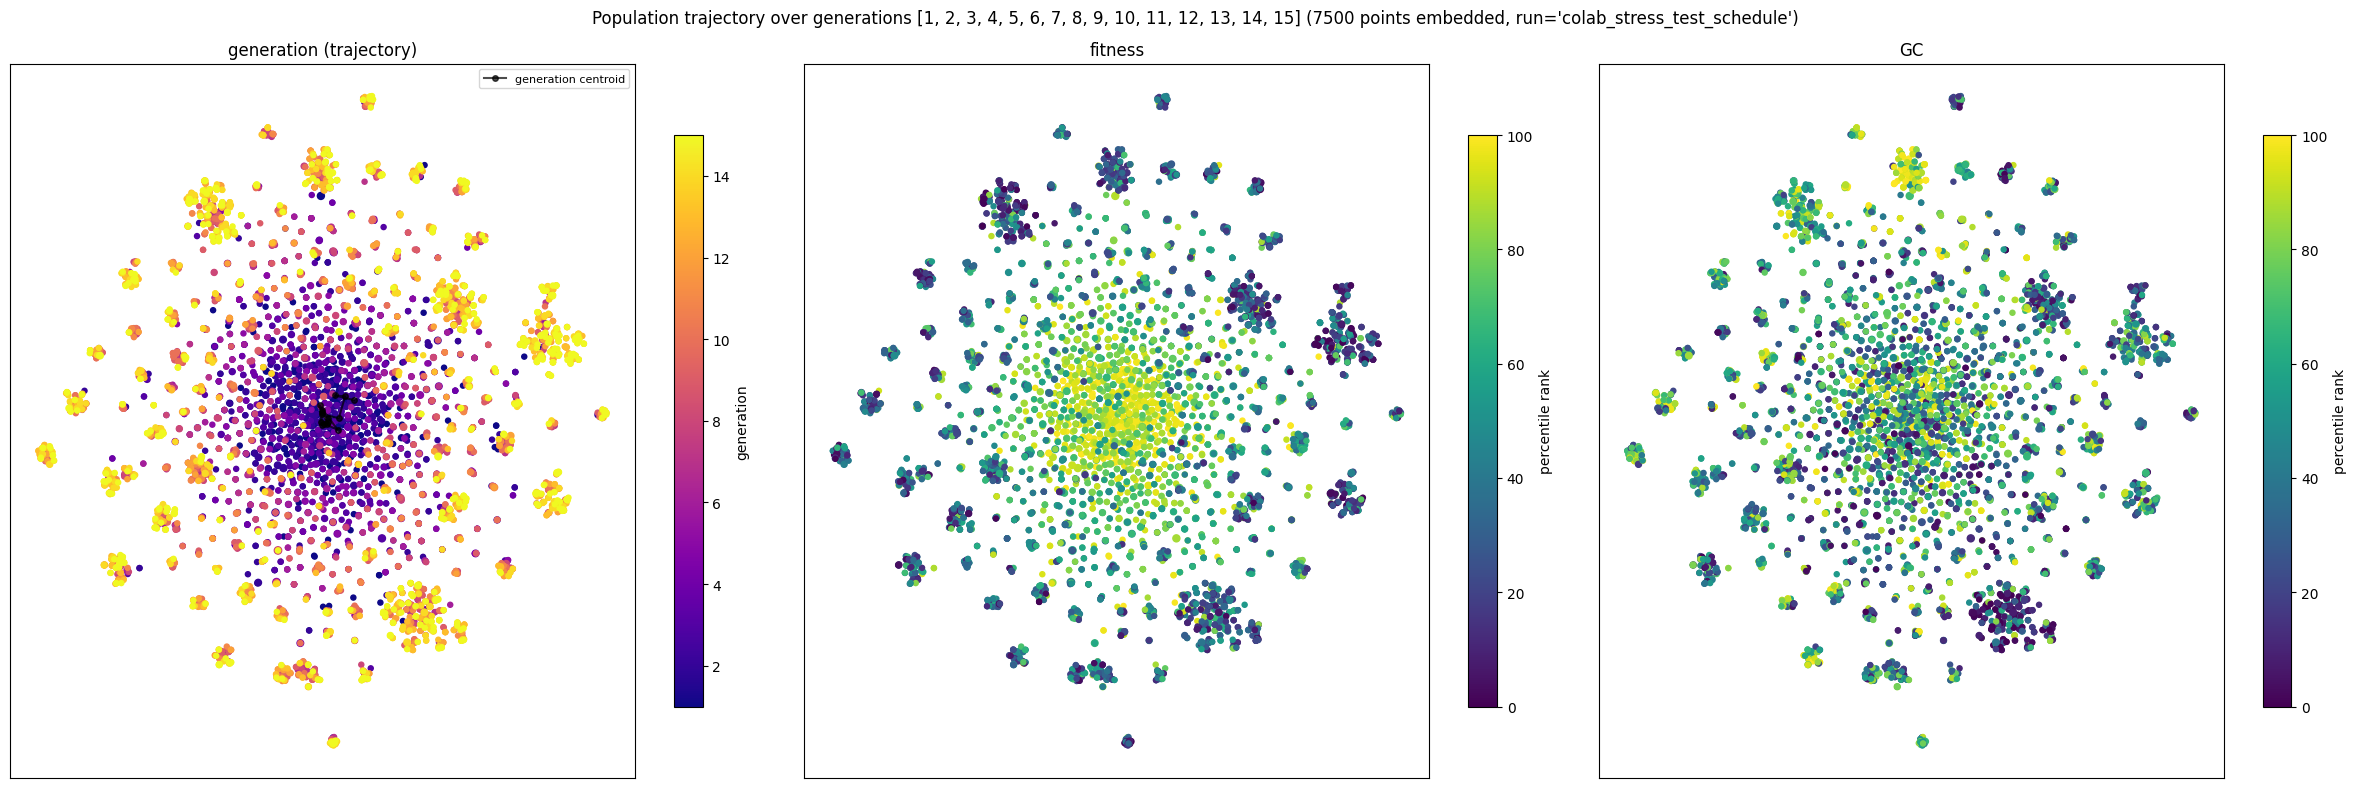

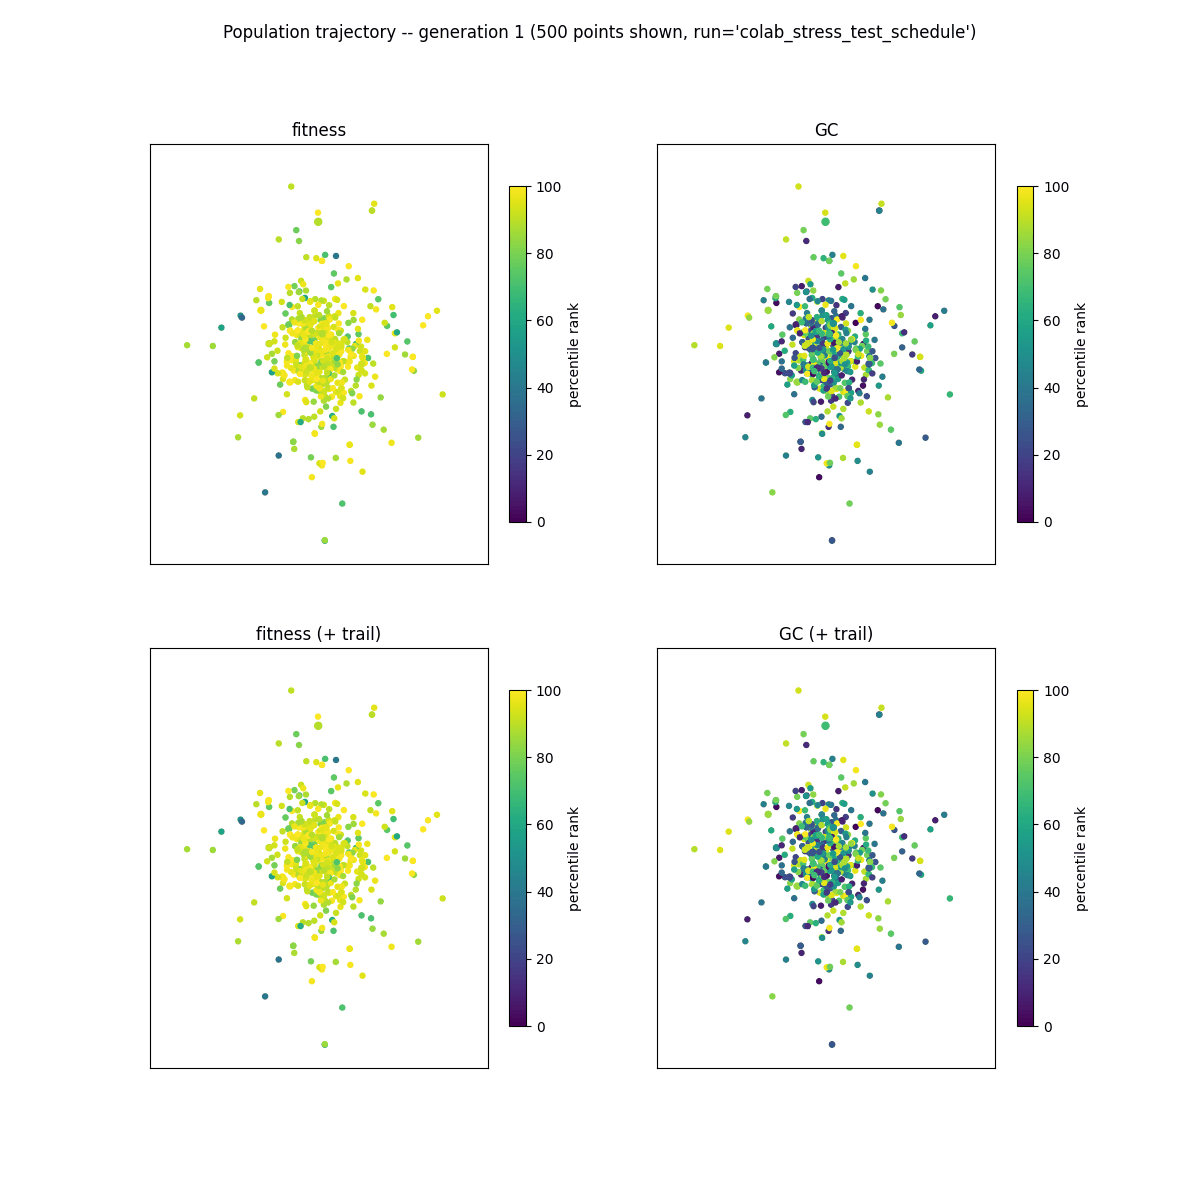

: 

In [ ]:
from genewriter.visualize import animate_population_trajectory, plot_population_tsne, plot_population_trajectory
import matplotlib.pyplot as plt

fig = plot_population_tsne(final_pop, CONFIG["WEIGHTS"], color_by=["fitness", "GC", "CodonPairBias", "Uracil"])
plt.show()

# Generation-over-time trajectory across every checkpoint save_gen() wrote
# for this run, all embedded in ONE shared t-SNE space -- see
# plot_population_trajectory()'s docstring. natural_codons (set by cell 2's
# pick_target(), None for TARGET_MODE="custom" or a malformed isoform) is
# embedded alongside the population as a flagged reference point, so you
# can see where nature's own sequence already sits relative to where the
# GA's population has moved -- useful for judging how far a rewrite target
# actually needed to travel.
traj_save_dir = CONFIG["RUN_GA_OPTIONS"]["save_dir"] if CONFIG["RUN_MODE"] == "run_ga" else CONFIG["SCHEDULE_SAVE_DIR"]
traj_run_name = CONFIG["RUN_GA_OPTIONS"]["run_name"] if CONFIG["RUN_MODE"] == "run_ga" else CONFIG["SCHEDULE_RUN_NAME"]

if traj_save_dir:
    fig2 = plot_population_trajectory(
        traj_save_dir, traj_run_name, CONFIG["WEIGHTS"],
        analysis_objects=analysis_objects, natural_codons=natural_codons, locvec=locvec,
        color_by=["fitness", "CodonPairBias", "Uracil"],
    )
    plt.show()

    # Same shared embedding as fig2 above, but animated: one frame per
    # generation instead of every generation overlaid on one static plot.
    # trail="both" (default) gives you a current-generation-only row AND a
    # fading-trail row in the same gif -- pass trail="current" or
    # trail="fade" instead if you only want one. Color is percentile rank
    # (0-100%), not the raw term value, so a skewed/outlier-heavy term
    # (e.g. RareCodons) still spreads across the full colormap instead of
    # collapsing everyone into one shade.
    anim = animate_population_trajectory(
        traj_save_dir, traj_run_name, CONFIG["WEIGHTS"],
        analysis_objects=analysis_objects, natural_codons=natural_codons, locvec=locvec,
        color_by=["fitness", "CodonPairBias", "Uracil"], trail="both", fps=2,
        out_path="population_trajectory.gif",
    )
    plt.close(anim._fig)  # the gif is what we want -- don't also leave the static setup figure open

    from IPython.display import Image
    display(Image(filename="population_trajectory.gif"))
else:
    print("No save_dir configured for this run (RUN_GA_OPTIONS['save_dir'] / SCHEDULE_SAVE_DIR is None) "
          "-- no per-generation checkpoints were written, so there's nothing to load a trajectory from.")